In [1]:
# %matplotlib ipympl
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import LightSource

In [2]:
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

In [3]:
n_qubits = 12
ticks = np.arange(0, n_qubits+0.1, 4)

_x, _y, _z = np.arange(0,n_qubits,1), np.arange(0,n_qubits,1), np.arange(0,n_qubits,1)
_xx, _yy, __zz = np.meshgrid(_x, _y, _z, indexing="ij")
x, y, z = _xx.ravel(), _yy.ravel(), __zz.ravel()

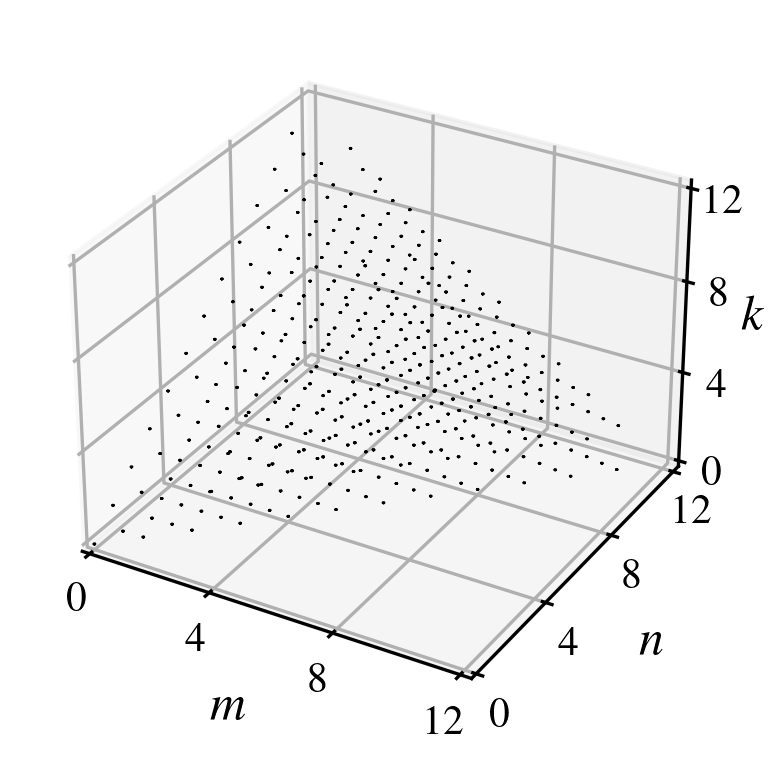

In [4]:
light = LightSource(0,20)
fig = plt.figure(figsize=(4,3),dpi=300)
ax = fig.add_subplot(projection='3d')
ax.set_xlabel(r'$m$', size=12, labelpad=-5)
ax.set_ylabel(r'$n$', size=12, labelpad=-5)
ax.set_zlabel(r'$k$', size=12, labelpad=-11)
ax.set_xlim(0,n_qubits+0.1)
ax.set_ylim(0,n_qubits+0.1)
ax.set_zlim(0,n_qubits+0.1)
ax.tick_params(axis='both', size=10, pad=-3)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)

r = 0.05

for (i,j,k) in zip(x,y,z):
    k_min = np.abs(i-j)
    if (k >= k_min and k <= min(i+j, 2*n_qubits - i - j) and k % 2 == k_min % 2):
        u, v = np.mgrid[0:2*np.pi:50j, 0:np.pi:50j]
        s_x = r*np.cos(u)*np.sin(v)
        s_y = r*np.sin(u)*np.sin(v)
        s_z = r*np.cos(v)

        ax.plot_surface(s_x+i, s_y+j, s_z+k, color = 'k', alpha=1)